In [64]:
import pandas as pd
df_pt1 = pd.read_csv('https://raw.githubusercontent.com/ross167/vanguard-ab-test/refs/heads/main/database/raw/df_final_web_data_pt_1.csv')
df_pt2 = pd.read_csv('https://raw.githubusercontent.com/ross167/vanguard-ab-test/refs/heads/main/database/raw/df_final_web_data_pt_2.csv')
df_pt = pd.concat([df_pt1,df_pt2])

df_pt.duplicated().sum()
df_pt = df_pt.drop_duplicates().reset_index().drop(columns="index")

In [65]:
df_exp = pd.read_csv('https://raw.githubusercontent.com/ross167/vanguard-ab-test/refs/heads/main/database/clean/df_final_experiment_clients_cleaned.csv')

df_demo = pd.read_csv('https://raw.githubusercontent.com/ross167/vanguard-ab-test/refs/heads/main/database/clean/df_final_demo.csv')

In [66]:
df_demo.drop(columns='Unnamed: 0',inplace=True)
df_demo

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth
0,836976,6.0,73.0,60.5,U,2.0,45105.30,6.0,9.0
1,2304905,7.0,94.0,58.0,U,2.0,110860.30,6.0,9.0
2,1439522,5.0,64.0,32.0,U,2.0,52467.79,6.0,9.0
3,1562045,16.0,198.0,49.0,M,2.0,67454.65,3.0,6.0
4,5126305,12.0,145.0,33.0,F,2.0,103671.75,0.0,3.0
...,...,...,...,...,...,...,...,...,...
70604,7993686,4.0,56.0,38.5,U,3.0,1411062.68,5.0,5.0
70605,8981690,12.0,148.0,31.0,M,2.0,101867.07,6.0,6.0
70606,333913,16.0,198.0,61.5,F,2.0,40745.00,3.0,3.0
70607,1573142,21.0,255.0,68.0,M,3.0,475114.69,4.0,4.0


In [67]:
df_exp.drop(columns='Unnamed: 0',inplace=True)
df_exp

,client_id,Variation
0,9988021,Test
1,8320017,Test
2,4033851,Control
3,1982004,Test
4,9294070,Control
...,...,...
50495,393005,Control
50496,2908510,Control
50497,7230446,Test
50498,5230357,Test


In [68]:
df_demo = df_demo.merge(df_exp, on= 'client_id', how="inner")

In [69]:
df_demo

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth,Variation
0,836976,6.0,73.0,60.5,U,2.0,45105.30,6.0,9.0,Test
1,2304905,7.0,94.0,58.0,U,2.0,110860.30,6.0,9.0,Control
2,1439522,5.0,64.0,32.0,U,2.0,52467.79,6.0,9.0,Test
3,1562045,16.0,198.0,49.0,M,2.0,67454.65,3.0,6.0,Test
4,5126305,12.0,145.0,33.0,F,2.0,103671.75,0.0,3.0,Control
...,...,...,...,...,...,...,...,...,...,...
50495,1780858,21.0,262.0,68.5,M,3.0,372100.59,6.0,9.0,Test
50496,6967120,21.0,260.0,68.5,M,3.0,4279873.38,6.0,9.0,Control
50497,5826160,20.0,249.0,56.5,F,2.0,44837.16,2.0,5.0,Test
50498,8739285,19.0,229.0,69.5,F,2.0,44994.24,1.0,4.0,Test


In [70]:
df_demo.rename(columns=lambda x: x.lower(), inplace=True)

In [71]:
df_pt["date_time"] = pd.to_datetime(df_pt["date_time"])

In [72]:
df = df_pt.copy()

In [73]:
df = df[df['client_id'].isin(df_demo['client_id'])]

In [ ]:
#df = df_pt.merge(df_exp, on="client_id", how="left")
#df.dropna(inplace=True)

In [74]:
step = {
    "start": 0,
    "step_1": 1,
    "step_2": 2,
    "step_3": 3,
    "confirm": 4}

In [75]:
df['process_step'] = df['process_step'].map(step)

In [76]:
df

,client_id,visitor_id,visit_id,process_step,date_time
0,9988021,580560515_7732621733,781255054_21935453173_531117,3,2017-04-17 15:27:07
1,9988021,580560515_7732621733,781255054_21935453173_531117,2,2017-04-17 15:26:51
2,9988021,580560515_7732621733,781255054_21935453173_531117,3,2017-04-17 15:19:22
3,9988021,580560515_7732621733,781255054_21935453173_531117,2,2017-04-17 15:19:13
4,9988021,580560515_7732621733,781255054_21935453173_531117,3,2017-04-17 15:18:04
...,...,...,...,...,...
629303,1574008,117364417_77840596075,528720790_71583064618_169151,0,2017-05-06 23:43:27
629346,2908510,814969699_90652851448,562606085_36368381773_92090,0,2017-05-10 22:57:17
629347,2908510,814969699_90652851448,562606085_36368381773_92090,2,2017-05-10 22:56:31
629348,2908510,814969699_90652851448,562606085_36368381773_92090,1,2017-05-10 22:56:23


In [77]:
def check_confirm(row):
        if (df[df['client_id'] == row['client_id']]['process_step'] == 4).sum() > 0:
            return "Confirmed"
        else:
            return "Not confirmed"

In [78]:
df['confirm_status'] = df.apply(check_confirm, axis=1)

In [102]:
df

,client_id,visitor_id,visit_id,process_step,date_time,confirm_status
0,9988021,580560515_7732621733,781255054_21935453173_531117,3,2017-04-17 15:27:07,Not confirmed
1,9988021,580560515_7732621733,781255054_21935453173_531117,2,2017-04-17 15:26:51,Not confirmed
2,9988021,580560515_7732621733,781255054_21935453173_531117,3,2017-04-17 15:19:22,Not confirmed
3,9988021,580560515_7732621733,781255054_21935453173_531117,2,2017-04-17 15:19:13,Not confirmed
4,9988021,580560515_7732621733,781255054_21935453173_531117,3,2017-04-17 15:18:04,Not confirmed
...,...,...,...,...,...,...
629303,1574008,117364417_77840596075,528720790_71583064618_169151,0,2017-05-06 23:43:27,Confirmed
629346,2908510,814969699_90652851448,562606085_36368381773_92090,0,2017-05-10 22:57:17,Not confirmed
629347,2908510,814969699_90652851448,562606085_36368381773_92090,2,2017-05-10 22:56:31,Not confirmed
629348,2908510,814969699_90652851448,562606085_36368381773_92090,1,2017-05-10 22:56:23,Not confirmed


In [112]:
df_confirm = df[['client_id', 'confirm_status']].drop_duplicates().reset_index(drop=True)

In [113]:
df_confirm

,client_id,confirm_status
0,9988021,Not confirmed
1,8320017,Confirmed
2,4033851,Confirmed
3,1982004,Confirmed
4,9294070,Not confirmed
...,...,...
50495,1129748,Confirmed
50496,8756202,Not confirmed
50497,433098,Confirmed
50498,1574008,Confirmed


In [101]:
df_demo

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth,variation
0,836976,6.0,73.0,60.5,U,2.0,45105.30,6.0,9.0,Test
1,2304905,7.0,94.0,58.0,U,2.0,110860.30,6.0,9.0,Control
2,1439522,5.0,64.0,32.0,U,2.0,52467.79,6.0,9.0,Test
3,1562045,16.0,198.0,49.0,M,2.0,67454.65,3.0,6.0,Test
4,5126305,12.0,145.0,33.0,F,2.0,103671.75,0.0,3.0,Control
...,...,...,...,...,...,...,...,...,...,...
50495,1780858,21.0,262.0,68.5,M,3.0,372100.59,6.0,9.0,Test
50496,6967120,21.0,260.0,68.5,M,3.0,4279873.38,6.0,9.0,Control
50497,5826160,20.0,249.0,56.5,F,2.0,44837.16,2.0,5.0,Test
50498,8739285,19.0,229.0,69.5,F,2.0,44994.24,1.0,4.0,Test


In [114]:
df_confirm_demo = df_demo.merge(df_confirm, on='client_id', how='left')

In [115]:
df_confirm_demo

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth,variation,confirm_status
0,836976,6.0,73.0,60.5,U,2.0,45105.30,6.0,9.0,Test,Confirmed
1,2304905,7.0,94.0,58.0,U,2.0,110860.30,6.0,9.0,Control,Confirmed
2,1439522,5.0,64.0,32.0,U,2.0,52467.79,6.0,9.0,Test,Not confirmed
3,1562045,16.0,198.0,49.0,M,2.0,67454.65,3.0,6.0,Test,Not confirmed
4,5126305,12.0,145.0,33.0,F,2.0,103671.75,0.0,3.0,Control,Not confirmed
...,...,...,...,...,...,...,...,...,...,...,...
50495,1780858,21.0,262.0,68.5,M,3.0,372100.59,6.0,9.0,Test,Confirmed
50496,6967120,21.0,260.0,68.5,M,3.0,4279873.38,6.0,9.0,Control,Confirmed
50497,5826160,20.0,249.0,56.5,F,2.0,44837.16,2.0,5.0,Test,Confirmed
50498,8739285,19.0,229.0,69.5,F,2.0,44994.24,1.0,4.0,Test,Confirmed


In [125]:
df_confirm_demo['bal'].describe()

count    5.050000e+04
mean     1.494791e+05
std      3.020093e+05
min      0.000000e+00
25%      3.986638e+04
50%      6.570465e+04
75%      1.399389e+05
max      1.632004e+07
Name: bal, dtype: float64

In [134]:
def bal_category(row):
    if row['bal'] < 3.986638e+04:
        return "small"
    elif row['bal'] > 1.399389e+05:
        return "medium"
    else:
        return "large"

In [135]:
df_confirm_demo['bal_cat'] = df_confirm_demo.apply(bal_category, axis=1)
df_confirm_demo

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth,variation,confirm_status,bal_cat
0,836976,6.0,73.0,60.5,U,2.0,45105.30,6.0,9.0,Test,Confirmed,large
1,2304905,7.0,94.0,58.0,U,2.0,110860.30,6.0,9.0,Control,Confirmed,large
2,1439522,5.0,64.0,32.0,U,2.0,52467.79,6.0,9.0,Test,Not confirmed,large
3,1562045,16.0,198.0,49.0,M,2.0,67454.65,3.0,6.0,Test,Not confirmed,large
4,5126305,12.0,145.0,33.0,F,2.0,103671.75,0.0,3.0,Control,Not confirmed,large
...,...,...,...,...,...,...,...,...,...,...,...,...
50495,1780858,21.0,262.0,68.5,M,3.0,372100.59,6.0,9.0,Test,Confirmed,medium
50496,6967120,21.0,260.0,68.5,M,3.0,4279873.38,6.0,9.0,Control,Confirmed,medium
50497,5826160,20.0,249.0,56.5,F,2.0,44837.16,2.0,5.0,Test,Confirmed,large
50498,8739285,19.0,229.0,69.5,F,2.0,44994.24,1.0,4.0,Test,Confirmed,large


In [136]:
pd.crosstab(df_confirm_demo["confirm_status"], df_confirm_demo["bal_cat"])

bal_cat,large,medium,small
confirm_status,,,
Confirmed,16918,8653,8550
Not confirmed,8332,3972,4075


In [ ]:
# H0: confirm_status and balance are independent
# H1: confirm_status and balance are dependent

# sl= 0.05

In [138]:
import scipy.stats as st
st.chi2_contingency(pd.crosstab(df_confirm_demo["confirm_status"], df_confirm_demo["bal_cat"]))

Chi2ContingencyResult(statistic=np.float64(9.256877840956676), pvalue=np.float64(0.00976999894922784), dof=2, expected_freq=array([[17060.5 ,  8530.25,  8530.25],
       [ 8189.5 ,  4094.75,  4094.75]]))

In [ ]:
#p-value is smaller than 0.05 so we reject the H0, confirm_status and balance are not independent, however on bar chart, we see the percentage is very indifferent
# => need to run the cramper to see how strong is the relation.

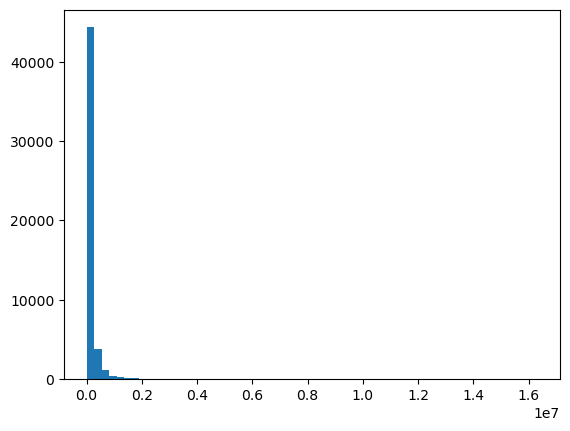

In [124]:
import matplotlib.pyplot as plt

plt.hist(df_confirm_demo['bal'], bins=60)
plt.show()